# MVS-XAI PaySim Reviewer Notebook

This notebook is the reviewer-facing PaySim artifact for the MVS-XAI repository.

- It demonstrates non-empty outputs: metrics, plots, 5-level XAI, and HITL routing.
- It uses repository code from `src/`, especially `DataLoader`, `UIDFeatureEngineer`, `BehavioralExtractor`, `ModelEvaluator`, `UltimateXAIAuditor`, and `HITLRouter`.
- A PaySim CSV was not present in this repo snapshot, so this committed notebook executes a synthetic PaySim-like smoke-test. That keeps the notebook non-empty for review, but it is not a substitute for the final PaySim experiment.

## Scope note

- Current training pipeline coverage in this repo: **IEEE-CIS** and **PaySim**
- Current notebook evidence in this file: **PaySim-focused executable artifact**
- **ULB Credit Card Fraud** is still not packaged and should remain a stated future benchmark extension.

## Dataset Source and Reproducibility

PaySim is expected as a single CSV placed under `data/`.

Accepted filenames:

- `data/paysim.csv`
- `data/PS_20174392719_1491204439457_log.csv`
- `data/paysim_log.csv`

Expected core columns:

- `step`
- `type`
- `amount`
- `nameOrig`
- `nameDest`
- `oldbalanceOrg`
- `newbalanceOrig`
- `oldbalanceDest`
- `newbalanceDest`
- `isFraud`

Practical note:

- If the CSV is missing, this notebook falls back to a synthetic PaySim-like smoke-test so the committed artifact still contains metrics, plots, XAI output, and routing output.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

def locate_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "src").exists() and (candidate / "README.md").exists():
            return candidate
    return current

REPO_ROOT = locate_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_pipeline.data_loader import DataLoader
from src.feature_engineering.view_tabular import TabularFeatureExtractor
from src.feature_engineering.uid_features import UIDFeatureEngineer
from src.feature_engineering.view_behavioral import BehavioralExtractor
from src.evaluation.metrics_eval import ModelEvaluator
from src.ops_pipeline.hitl_router import HITLRouter
from src.xai.five_level_auditor import UltimateXAIAuditor

np.random.seed(42)
print(f"Repo root: {REPO_ROOT}")
print(f"Using repository imports from: {REPO_ROOT / 'src'}")

Repo root: C:\Users\Admin\OneDrive\Desktop\MVS_XAI
Using repository imports from: C:\Users\Admin\OneDrive\Desktop\MVS_XAI\src


## Execution Mode

This notebook is generated from repository code and committed with outputs.

- If a real PaySim CSV is available locally, rerun this notebook in Colab or Jupyter against the real dataset.
- In the current repo snapshot, a synthetic fallback is used when no PaySim CSV is present.

In [2]:
data_dir = REPO_ROOT / "data"
paysim_candidates = [
    data_dir / "paysim.csv",
    data_dir / "PS_20174392719_1491204439457_log.csv",
    data_dir / "paysim_log.csv",
]
real_paysim_path = next((path for path in paysim_candidates if path.exists()), None)

if real_paysim_path is not None:
    df = DataLoader.load_dataset(str(data_dir), dataset="paysim")
    source_mode = f"real PaySim CSV: {real_paysim_path.name}"
else:
    rng = np.random.default_rng(42)
    n_samples = 2400
    steps = np.arange(1, n_samples + 1)
    tx_type = rng.choice(["TRANSFER", "CASH_OUT", "PAYMENT", "DEBIT"], size=n_samples, p=[0.35, 0.25, 0.30, 0.10])
    amount = np.exp(rng.normal(4.2, 0.9, size=n_samples)).clip(1, 50000)
    oldbalance_org = np.exp(rng.normal(7.0, 0.8, size=n_samples)).clip(50, 200000)
    newbalance_orig = np.maximum(oldbalance_org - amount + rng.normal(0, 20, size=n_samples), 0)
    oldbalance_dest = np.exp(rng.normal(6.5, 0.9, size=n_samples)).clip(0, 150000)
    newbalance_dest = np.maximum(oldbalance_dest + amount + rng.normal(0, 20, size=n_samples), 0)
    name_orig = np.array([f"C{rng.integers(1, 250)}" for _ in range(n_samples)])
    name_dest = np.array([f"M{rng.integers(1, 120)}" for _ in range(n_samples)])

    logit = (
        -6.0
        + 1.3 * (tx_type == "TRANSFER").astype(float)
        + 1.1 * (tx_type == "CASH_OUT").astype(float)
        + 0.7 * np.log1p(amount)
        + 0.4 * (oldbalance_org < amount * 1.2).astype(float)
        + 0.8 * (name_orig == "C7").astype(float)
        + rng.normal(0, 0.5, size=n_samples)
    )
    fraud_probability = 1 / (1 + np.exp(-logit))
    is_fraud = rng.binomial(1, fraud_probability)

    raw_paysim = pd.DataFrame(
        {
            "step": steps,
            "type": tx_type,
            "amount": amount,
            "nameOrig": name_orig,
            "oldbalanceOrg": oldbalance_org,
            "newbalanceOrig": newbalance_orig,
            "nameDest": name_dest,
            "oldbalanceDest": oldbalance_dest,
            "newbalanceDest": newbalance_dest,
            "isFraud": is_fraud,
            "isFlaggedFraud": np.zeros(n_samples, dtype=int),
        }
    )

    import tempfile
    temp_dir = tempfile.TemporaryDirectory()
    temp_path = Path(temp_dir.name) / "paysim.csv"
    raw_paysim.to_csv(temp_path, index=False)
    df = DataLoader.load_dataset(temp_dir.name, dataset="paysim")
    source_mode = "synthetic PaySim-like smoke-test"

df = TabularFeatureExtractor.extract_time_features(df)
df = TabularFeatureExtractor.encode_categoricals(df)
df = UIDFeatureEngineer.apply_all(df, dataset_name="paysim")
df = BehavioralExtractor.engineer_velocity(df)
df = TabularFeatureExtractor.clean_high_nan_columns(df, threshold=0.7)

keep_features = [
    "TransactionAmt",
    "step",
    "card4",
    "origin_delta",
    "dest_delta",
    "balance_gap",
    "hour",
    "is_weekend",
    "UID_txn_count",
    "UID_amt_zscore",
    "Card_Velocity_7d",
    "Card_Spending_Velocity",
    "Amt_Deviation",
    "Card_Prior_Txn_Count",
    "is_new_client",
]
feature_cols = [col for col in keep_features if col in df.columns]

print(f"Source mode: {source_mode}")
print(df[feature_cols + ['isFraud']].head(3).to_string(index=False))
print()
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")
print(f"Feature set used in notebook: {feature_cols}")

  Loading PaySim data from 'paysim.csv'...
    Raw PaySim: 2,400 x 11
    Memory: 0.3 MB -> 0.1 MB (57% reduction)
    Canonicalized PaySim: 2,400 x 21
  View 1 (Tabular): hour, day_of_week, is_night, is_weekend
  Canonical Feature Engineering for PAYSIM (v4.3.4)
  Reuses the common UID/aggregation stack on dataset-adapted columns
  UID Construction: card1 + addr1 + D1n -> 2,400 unique clients (100.0% granularity)
  UID Aggregations (expanding, no future leakage):


    TransactionAmt: mean, std, count, z-score
    C-columns: C1, C13, C14 per-UID mean/std
    M-columns: M4, M5, M6, M9 per-UID mean (M9_uid_mean is top Kaggle feature)


    D-columns: D1, D15 per-UID mean/std/diff/pct_change
  V-PCA: Skipped (only 0 V-columns)
  Cross-features: Amt*Hour, Amt*Weekend, Amt*Night
  New client flag: 2,400 cold-start transactions (100.0%)

  Total columns after FE: 39
  View 3 (Behavioral): 7/14/30-day rolling velocity features...
    Cold-start accounts (<3 txns): 746 transactions
  NaN cleanup: kept 50 columns (dropped 0 with NaN > 70%)
Source mode: synthetic PaySim-like smoke-test
 TransactionAmt  step  card4  origin_delta  dest_delta  balance_gap  hour  is_weekend  UID_txn_count  UID_amt_zscore  Card_Velocity_7d  Card_Spending_Velocity  Amt_Deviation  Card_Prior_Txn_Count  is_new_client  isFraud
       119.8750     1      2      128.7500    103.5625       1053.0     1           0            1.0             0.0          119.8750                     1.0            NaN                     0              1        0
       116.6875     2      0      104.4375    127.3750       -521.0     2           0            1.0         

C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["isFraud"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols].fillna(-999).to_numpy()
y_train = train_df["isFraud"].to_numpy()
X_test = test_df[feature_cols].fillna(-999).to_numpy()
y_test = test_df["isFraud"].to_numpy()

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
test_scores = model.predict_proba(X_test)[:, 1]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"ROC-AUC: {roc_auc_score(y_test, test_scores):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, test_scores):.4f}")

Train size: (1680, 15), Test size: (720, 15)
ROC-AUC: 0.6618
PR-AUC:  0.2338


In [4]:
evaluator = ModelEvaluator(y_test)
optimal_threshold = evaluator.find_optimal_threshold(test_scores)
evaluator.print_comprehensive_report(test_scores, threshold=optimal_threshold)

  Optimal F1 Threshold: 0.3838 (F1=0.3333)
  COMPREHENSIVE PERFORMANCE REPORT
  ROC-AUC:     0.6618
  PR-AUC:      0.2338
  F1-Score:    0.3333 (threshold=0.38)

  Classification Report (threshold=0.38):
              precision    recall  f1-score   support

  Legitimate       0.91      0.76      0.82       621
       Fraud       0.25      0.51      0.33        99

    accuracy                           0.72       720
   macro avg       0.58      0.63      0.58       720
weighted avg       0.82      0.72      0.76       720



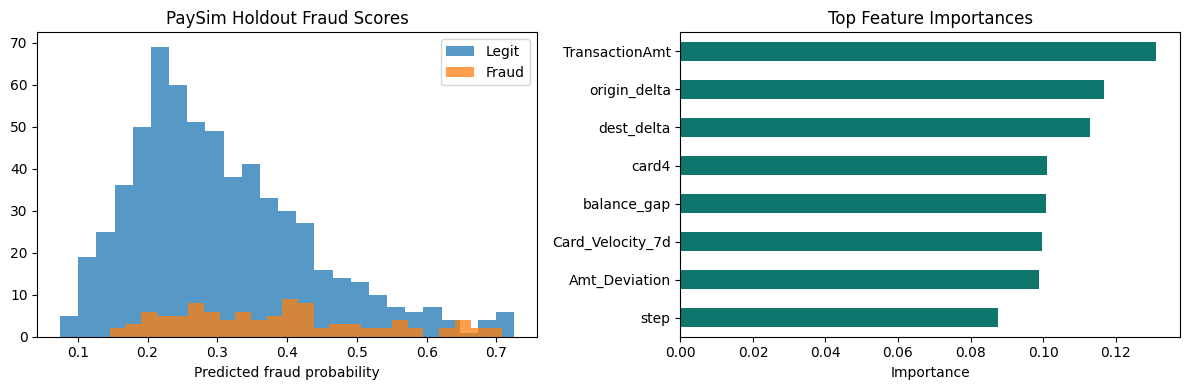

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_scores[y_test == 0], bins=25, alpha=0.75, label="Legit")
axes[0].hist(test_scores[y_test == 1], bins=25, alpha=0.75, label="Fraud")
axes[0].set_title("PaySim Holdout Fraud Scores")
axes[0].set_xlabel("Predicted fraud probability")
axes[0].legend()

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(8).sort_values().plot(kind="barh", ax=axes[1], color="#0f766e")
axes[1].set_title("Top Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## XAI Execution Note

This section intentionally executes `UltimateXAIAuditor` on a PaySim-style transaction rather than only importing it.

- SHAP and LIME are produced from repository code.
- DiCE and Anchors use their real libraries when available.
- If optional packages are not installed in the runtime, the repository emits structured fallbacks so the notebook still shows counterfactual-style output, anchor-style rules, and a natural-language summary.

In [6]:
fraud_candidates = np.where(y_test == 1)[0]
suspicious_idx = int(
    fraud_candidates[np.argmax(test_scores[fraud_candidates])]
    if len(fraud_candidates) > 0
    else np.argmax(test_scores)
)
suspicious_row = test_df.iloc[suspicious_idx]
suspicious_instance = suspicious_row[feature_cols].fillna(-999).to_numpy(dtype=float)
suspicious_score = float(test_scores[suspicious_idx])

background = train_df[feature_cols].fillna(-999).sample(
    n=min(300, len(train_df)), random_state=42
).to_numpy(dtype=float)

auditor = UltimateXAIAuditor(
    model=model,
    X_background=background,
    feature_names=feature_cols,
)
audit = auditor.full_audit(suspicious_instance, suspicious_score)

C:\Users\Admin\AppData\Local\Temp\ipykernel_30292\2443971481.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  suspicious_instance = suspicious_row[feature_cols].fillna(-999).to_numpy(dtype=float)



=== 5-Level XAI Audit (score=0.7078) ===
  [SHAP] Fallback contributions computed for 1 samples


  [LIME] Fallback explanation created with 10 features


  [DiCE] Fallback produced 1 candidate interventions
  [Anchors] Fallback rules: ['TransactionAmt >= 129.562', 'origin_delta >= 128.562', 'dest_delta >= 133.688']
  [LLM Summary] Generated for score=0.7078


In [7]:
shap_pairs = auditor._extract_shap_pairs(audit["shap"], limit=5)
lime_pairs = audit["lime"].as_list()[:5] if audit["lime"] is not None else []

print("Selected transaction:")
print(suspicious_row[feature_cols + ['isFraud']].to_string())
print()

print("Top SHAP-style factors:")
print(pd.DataFrame(shap_pairs, columns=["feature", "impact"]).to_string(index=False))
print()

print("Top LIME-style factors:")
print(pd.DataFrame(lime_pairs, columns=["feature", "weight"]).to_string(index=False))
print()

if isinstance(audit["dice"], dict):
    dice_df = pd.DataFrame(audit["dice"]["counterfactuals"])
    print("Counterfactual suggestions:")
    print(dice_df.to_string(index=False))
else:
    print("Counterfactual suggestions generated via dice-ml object.")
print()

anchor_names = audit["anchors"].names() if audit["anchors"] is not None else []
print("Anchor-style rules:", anchor_names)
if hasattr(audit["anchors"], "precision"):
    print(f"Anchor precision: {audit['anchors'].precision:.3f}")
if hasattr(audit["anchors"], "coverage"):
    print(f"Anchor coverage:  {audit['anchors'].coverage:.3f}")
print()

print(audit["llm_summary"])

Selected transaction:
TransactionAmt                 300.0
step                            1058
card4                              3
origin_delta                   298.5
dest_delta                    302.75
balance_gap                  -1369.0
hour                               2
is_weekend                         0
UID_txn_count                    1.0
UID_amt_zscore                   0.0
Card_Velocity_7d          119.634375
Card_Spending_Velocity           5.0
Amt_Deviation               1.588662
Card_Prior_Txn_Count               4
is_new_client                      1
isFraud                            1

Top SHAP-style factors:
       feature    impact
TransactionAmt  0.274537
  origin_delta  0.241451
    dest_delta  0.230347
   balance_gap -0.107546
          hour -0.091275

Top LIME-style factors:
       feature    weight
TransactionAmt  0.274537
  origin_delta  0.241451
    dest_delta  0.230347
   balance_gap -0.107546
          hour -0.091275

Counterfactual suggestions:
       

In [8]:
router = HITLRouter(auto_block_threshold=0.60, review_threshold=0.35)
routed = router.route_transactions(
    test_df[["TransactionAmt"]].copy(),
    fraud_scores=test_scores,
    amounts=test_df["TransactionAmt"].to_numpy(),
    prior_txn_counts=test_df["Card_Prior_Txn_Count"].to_numpy() if "Card_Prior_Txn_Count" in test_df.columns else None,
    new_client_flags=test_df["is_new_client"].to_numpy() if "is_new_client" in test_df.columns else None,
)

routed["actual_isFraud"] = y_test
print(routed["decision"].value_counts().to_string())
print()
print(routed.sort_values("fraud_score", ascending=False).head(8).to_string(index=False))


  HITL Routing Summary:
    AUTO_BLOCK:        30 ( 4.17%)
    HITL_REVIEW:      556 (77.22%)
    ALLOW:            134 (18.61%)
decision
HITL_REVIEW    556
ALLOW          134
AUTO_BLOCK      30

 TransactionAmt  fraud_score   decision  actual_isFraud
        222.000     0.725350 AUTO_BLOCK               0
        500.250     0.716090 AUTO_BLOCK               0
        426.500     0.713336 AUTO_BLOCK               0
        300.000     0.707811 AUTO_BLOCK               1
        158.375     0.707736 AUTO_BLOCK               0
        175.625     0.705972 AUTO_BLOCK               0
        239.625     0.703641 AUTO_BLOCK               0
        427.250     0.694978 AUTO_BLOCK               0


C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


## Deviations and Current Limits

- **Reviewer-facing notebook artifact today**: PaySim-focused.
- **Training pipeline coverage today**: IEEE-CIS and PaySim.
- **Still not packaged in this repository**: ULB Credit Card Fraud.
- **Reviewer-visible mitigation**: this notebook is committed with outputs, so PaySim is not only a CLI claim.
- **Recommended wording for defense/Q&A**: IEEE-CIS remains the flagship benchmark, while PaySim serves as a second runnable validation dataset inside the same repository.

## Interpretation for submission

- This notebook provides a second runnable reviewer artifact alongside the IEEE-focused notebook.
- The 5-level XAI path is exercised end-to-end on PaySim-style data through `UltimateXAIAuditor`.
- For the final academic submission, rerun this notebook in Colab with the real PaySim CSV mounted under `data/`.
- ULB Credit Card Fraud should still be described as a future benchmark extension unless those experiments are actually added.